# Fake News Detection — M516 Business Project in Big Data & AI

**Dataset:** https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

**Label encoding:** `0 = Real`, `1 = Fake`  
**Task:** Binary text classification (NLP) to distinguish real vs. fake news.

## 0. Install dependencies (run once)

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud joblib streamlit tensorflow

## 1. Imports & setup

In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2. Load data

In [ ]:
df = pd.read_csv('WELFake_Dataset.csv')
df = df.drop(columns=['Unnamed: 0'])
print(df.shape)
df.head()

(72134, 3)


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
print(df.info())
print()
print(df['label'].value_counts())
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None

label
1    37106
0    35028
Name: count, dtype: int64

title    558
text      39
label      0
dtype: int64


## 3. Exploratory Data Analysis

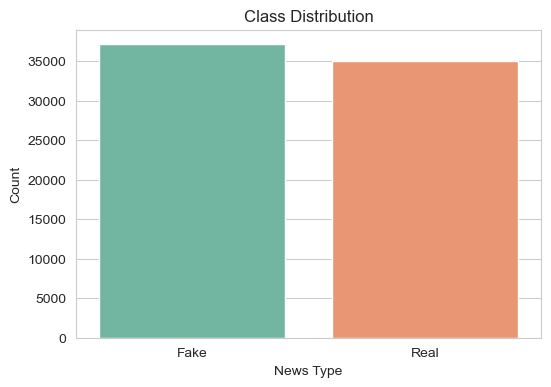

In [ ]:
df['label_name'] = df['label'].map({0: 'Real', 1: 'Fake'})

plt.figure(figsize=(6, 4))
sns.countplot(x='label_name', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()

In [ ]:
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['content'] = (df['title'] + ' ' + df['text']).str.strip()
df = df[df['content'].str.len() > 0].reset_index(drop=True)
print(df.shape)

(72134, 5)


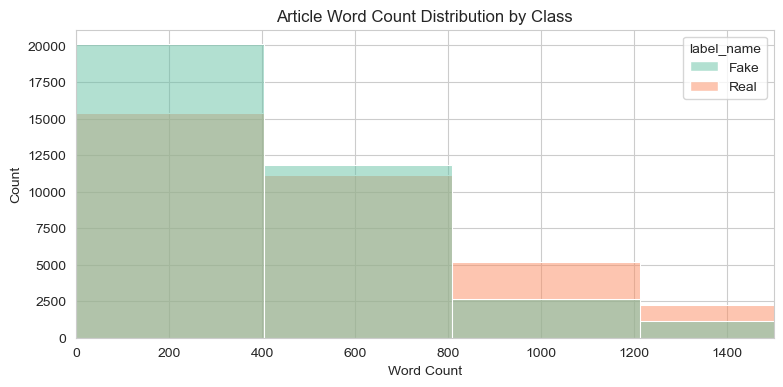

              count        mean         std  min    25%    50%    75%      max
label_name                                                                    
Fake        37106.0  518.798927  677.044244  1.0  230.0  383.0  583.0  24243.0
Real        35028.0  588.662156  563.940258  4.0  252.0  438.0  795.0  14650.0


In [ ]:
df['word_count'] = df['content'].str.split().apply(len)

plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='word_count', hue='label_name', bins=60, palette='Set2')
plt.xlim(0, 1500)
plt.title('Article Word Count Distribution by Class')
plt.xlabel('Word Count')
plt.show()

print(df.groupby('label_name')['word_count'].describe())

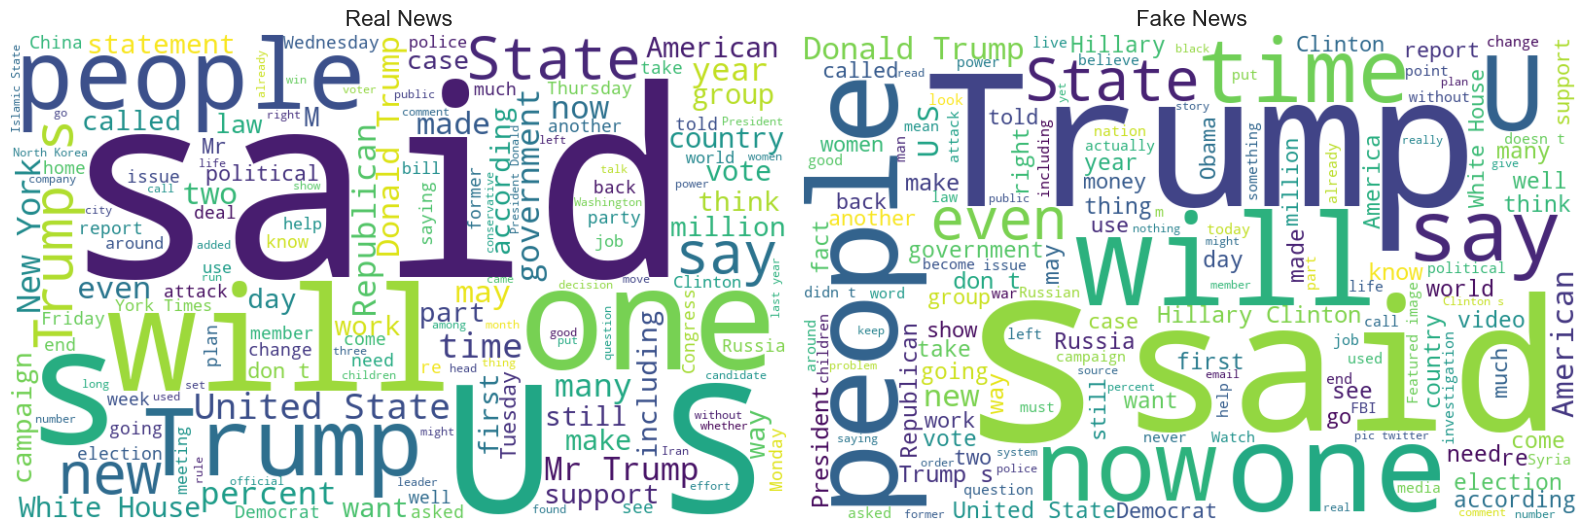

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, lbl in zip(axes, ['Real', 'Fake']):
    sample_text = ' '.join(df[df['label_name'] == lbl]['content'].sample(3000, random_state=RANDOM_STATE))
    wc = WordCloud(width=800, height=500, background_color='white', max_words=150).generate(sample_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{lbl} News', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Text preprocessing

In [ ]:
def clean_text(t):
    t = t.lower()
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'<.*?>', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['clean'] = df['content'].apply(clean_text)
df[['content', 'clean']].head(2)

,content,clean
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...
1,Did they post their votes for Hillary already?,did they post their votes for hillary already


## 5. Train/test split & vectorisation

In [ ]:
X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(X_train.shape, X_test.shape)

(57707,) (14427,)


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2),
                             max_features=50000, min_df=5, max_df=0.9, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(X_train_vec.shape)

(57707, 50000)


## 6. Baseline model comparison

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'Linear SVM': LinearSVC(C=1.0, random_state=RANDOM_STATE),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=RANDOM_STATE),
    'Multinomial NB': MultinomialNB(alpha=0.1),
}

results = []
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Passive Aggressive,0.974700,0.970651,0.980461,0.975531
1,Linear SVM,0.973522,0.968330,0.980596,0.974424
2,Logistic Regression,0.959728,0.955757,0.966447,0.961072
3,Multinomial NB,0.892008,0.886181,0.906482,0.896216


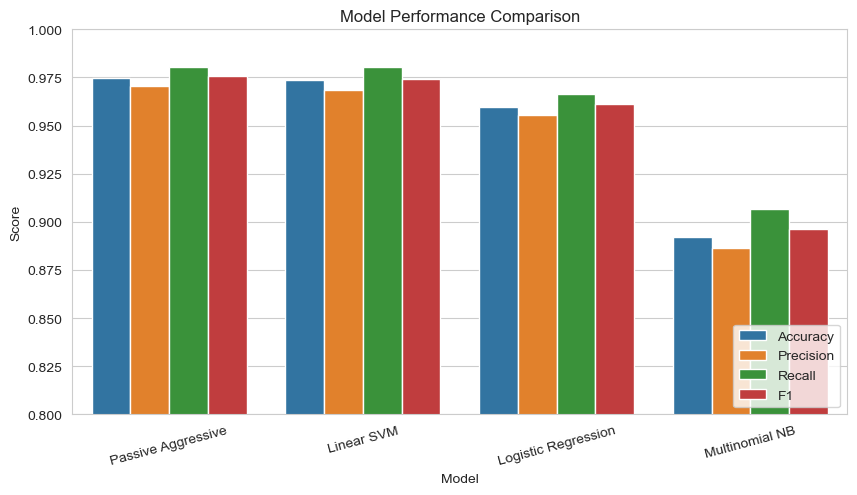

In [ ]:
results_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 5))
sns.barplot(data=results_melt, x='Model', y='Score', hue='Metric')
plt.ylim(0.8, 1.0)
plt.title('Model Performance Comparison')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()

## 7. Hyperparameter tuning
_This cell takes a few minutes._

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [30000, 50000],
    'tfidf__min_df': [5],
    'clf__C': [0.5, 1.0, 5.0],
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))
best_model = grid.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'clf__C': 5.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.967


## 8. Final evaluation

In [ ]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

              precision    recall  f1-score   support

        Real       0.97      0.96      0.97      7006
        Fake       0.96      0.97      0.97      7421

    accuracy                           0.97     14427
   macro avg       0.97      0.97      0.97     14427
weighted avg       0.97      0.97      0.97     14427



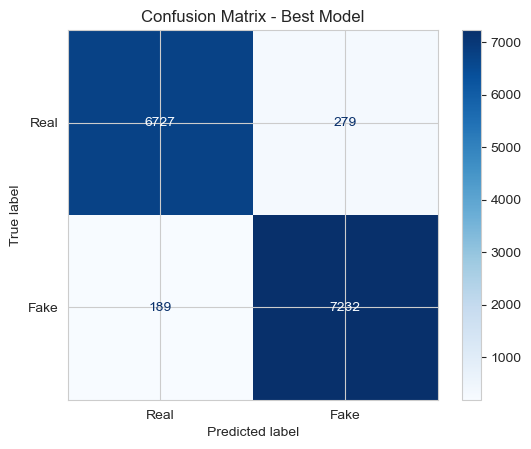

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Best Model')
plt.show()

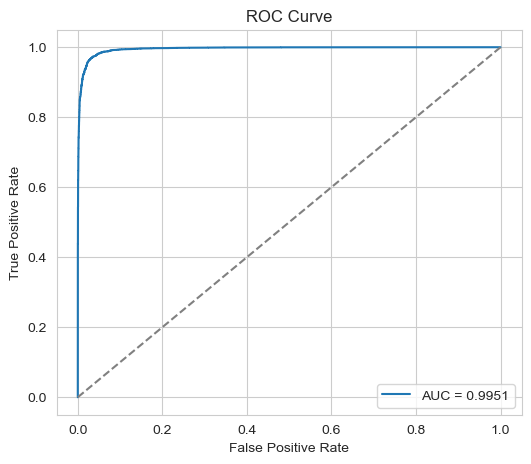

In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 9. Cross-validation
_This cell takes a few minutes._

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
print('CV F1 scores:', np.round(cv_scores, 4))
print(f'Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

CV F1 scores: [0.9713 0.9657 0.9688 0.9685 0.9686]
Mean F1: 0.9686 (+/- 0.0018)


## 10. Explainability — most influential terms

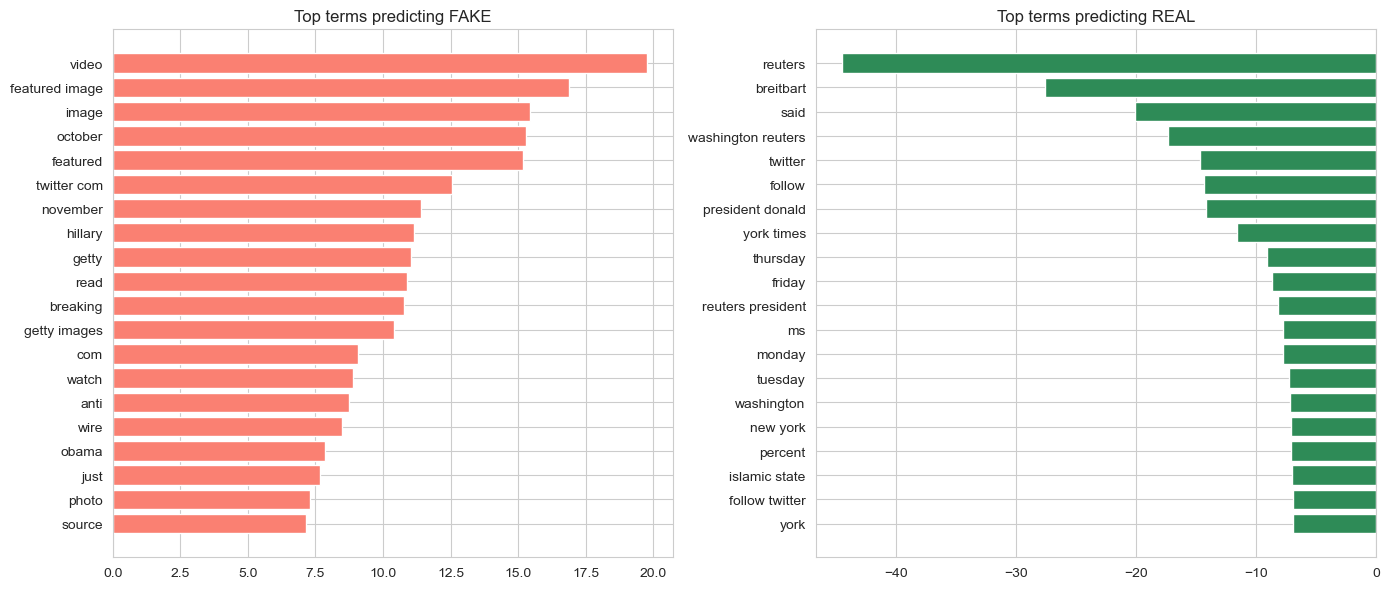

In [ ]:
final_vec = best_model.named_steps['tfidf']
final_clf = best_model.named_steps['clf']
feature_names = np.array(final_vec.get_feature_names_out())
coefs = final_clf.coef_[0]

top_fake = np.argsort(coefs)[-20:][::-1]
top_real = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(feature_names[top_fake][::-1], coefs[top_fake][::-1], color='salmon')
axes[0].set_title('Top terms predicting FAKE')
axes[1].barh(feature_names[top_real][::-1], coefs[top_real][::-1], color='seagreen')
axes[1].set_title('Top terms predicting REAL')
plt.tight_layout()
plt.show()

## 11. Error analysis

In [ ]:
test_df = pd.DataFrame({'text': X_test.values, 'true': y_test.values, 'pred': y_pred})
errors = test_df[test_df['true'] != test_df['pred']]
print(f'Misclassified: {len(errors)} of {len(test_df)} ({100 * len(errors) / len(test_df):.2f}%)')
print()

for _, row in errors.head(5).iterrows():
    true_lbl = 'Real' if row['true'] == 0 else 'Fake'
    pred_lbl = 'Real' if row['pred'] == 0 else 'Fake'
    print(f'TRUE: {true_lbl} | PRED: {pred_lbl}')
    print(row['text'][:200], '...')
    print('-' * 80)

Misclassified: 468 of 14427 (3.24%)

TRUE: Real | PRED: Fake
video anti western hindu extremists assault couples in india on valentine s day breitbart lovers in india can bring a little sadism into their romance without shelling out for tickets to the fifty sha ...
--------------------------------------------------------------------------------
TRUE: Real | PRED: Fake
scary times for california farmers as snowpack hits record lows the water outlook in drought racked california just got a lot worse snowpack levels across the entire sierra nevada are now the lowest i ...
--------------------------------------------------------------------------------
TRUE: Fake | PRED: Real
follow the money mexican giveaway of millions of flat screen tv s to the poor raises questions follow the money on this one mexico is spending over billion dollars on flat screens for millions at a co ...
--------------------------------------------------------------------------------
TRUE: Real | PRED: Fake
the bosto

## 12. Generalisation test on unseen headlines

In [ ]:
samples = [
    "Breaking: Scientists confirm drinking coffee makes you immortal, government hiding the truth!!!",
    "The European Central Bank kept interest rates unchanged on Thursday, citing stable inflation expectations.",
    "SHOCKING! Celebrity reveals aliens built the pyramids in secret interview you won't believe.",
    "The health ministry reported a decline in seasonal flu cases compared with the previous year.",
]

for s in samples:
    c = clean_text(s)
    p = best_model.predict([c])[0]
    conf = best_model.predict_proba([c])[0].max()
    print(f'[{"FAKE" if p == 1 else "REAL"} | conf {conf:.2f}] {s[:70]}')

[FAKE | conf 1.00] Breaking: Scientists confirm drinking coffee makes you immortal, gover
[REAL | conf 0.65] The European Central Bank kept interest rates unchanged on Thursday, c
[FAKE | conf 1.00] SHOCKING! Celebrity reveals aliens built the pyramids in secret interv
[FAKE | conf 0.81] The health ministry reported a decline in seasonal flu cases compared 


## 13. Save the trained model

In [ ]:
joblib.dump(best_model, 'fake_news_model.joblib')
print('Saved: fake_news_model.joblib')

Saved: fake_news_model.joblib
